# Stage 0: Setup & Imports

In [14]:
from google.colab import drive
drive.mount('/content/drive')

import os
PROJECT_DIR = '/content/drive/MyDrive/multilexsum_project'
OUT_DIR = os.path.join(PROJECT_DIR, 'eda_outputs')
os.makedirs(OUT_DIR, exist_ok=True)
print("Outputs will be saved to:", OUT_DIR)

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).
Outputs will be saved to: /content/drive/MyDrive/multilexsum_project/eda_outputs


In [3]:
!pip install -q datasets transformers

In [4]:
!pip install -q evaluate rouge_score

In [5]:
import json
import zipfile
import urllib.request
import pickle
from pathlib import Path
from tqdm import tqdm

import numpy as np
import matplotlib.pyplot as plt
from IPython.display import Image, display

OUT_DIR = Path(OUT_DIR)

# Stage 1: Data Acquisition & Caching

In [6]:
import requests
from tqdm import tqdm

BASE_URL = "https://huggingface.co/datasets/allenai/multi_lexsum/resolve/main/releases/v20230518"
RAW_DIR = Path("/content/multilexsum_raw")
RAW_DIR.mkdir(exist_ok=True)

def download_with_progress(url, dest_path):
    if dest_path.exists():
        print(f"Already downloaded: {dest_path.name}")
        return
    resp = requests.get(url, stream=True)
    resp.raise_for_status()
    total = int(resp.headers.get("content-length", 0))
    with open(dest_path, "wb") as f, tqdm(
        total=total, unit="B", unit_scale=True, desc=dest_path.name
    ) as bar:
        for chunk in resp.iter_content(chunk_size=1024 * 1024):
            f.write(chunk)
            bar.update(len(chunk))

def load_multilexsum():
    parsed_path = Path("/content/drive/MyDrive/multilexsum_parsed.pkl")

    # Fast path: fully parsed data already on Drive
    if parsed_path.exists():
        print("Found cached parsed data on Drive — loading instantly, no download needed.")
        with open(parsed_path, "rb") as f:
            return pickle.load(f)

    # Medium path: raw files already on Drive, just need re-parsing
    drive_raw_dir = Path("/content/drive/MyDrive/multilexsum_raw")
    if drive_raw_dir.exists():
        print("Found cached raw files on Drive — skipping download, parsing now.")
        raw_dir = drive_raw_dir
    else:
        print("No cache found — downloading from Hugging Face (this will take ~5 min).")
        raw_dir = RAW_DIR
        files = {"train": "train.json", "dev": "dev.json", "test": "test.json", "sources": "sources.json"}
        for name, fname in files.items():
            download_with_progress(f"{BASE_URL}/{fname}", raw_dir / fname)

    with open(raw_dir / "sources.json", "r") as f:
        sources = json.load(f)

    def load_split(path):
        with open(path, "r") as f:
            cases = [json.loads(line) for line in f.read().splitlines()]
        return [{
            "id": c["case_id"],
            "sources": [sources[d]["doc_text"] for d in c["case_documents"]],
            "sources_metadata": [
                {
                    "is_ocr": sources[d].get("is_ocr", False),
                    "doc_type": sources[d].get("doc_type", "unknown")
                } for d in c["case_documents"]
            ],
            "summary/long": c.get("summary/long"),
            "summary/short": c.get("summary/short"),
            "summary/tiny": c.get("summary/tiny"),
        } for c in cases]

    data = {
        "train": load_split(raw_dir / "train.json"),
        "validation": load_split(raw_dir / "dev.json"),
        "test": load_split(raw_dir / "test.json"),
    }

    # Save the parsed result to Drive so next time hits the fast path
    with open(parsed_path, "wb") as f:
        pickle.dump(data, f)

    return data

In [7]:
data = load_multilexsum()
print({split: len(items) for split, items in data.items()})

Found cached parsed data on Drive — loading instantly, no download needed.
{'train': 3177, 'validation': 454, 'test': 908}


# Stage 2: Exploratory Data Analysis (EDA)

In [8]:
def word_count(text):
    return len(text.split()) if text else 0

def run_eda(data):
    summary = {}

    split_sizes = {split: len(items) for split, items in data.items()}
    summary["split_sizes"] = split_sizes

    missing_report = {}
    for split, items in data.items():
        missing_report[split] = {
            "missing_sources": sum(1 for x in items if not x.get("sources")),
            "missing_summary/tiny": sum(1 for x in items if not x.get("summary/tiny")),
            "missing_summary/short": sum(1 for x in items if not x.get("summary/short")),
            "missing_summary/long": sum(1 for x in items if not x.get("summary/long")),
        }
    summary["missing_report"] = missing_report

    all_items = [x for items in data.values() for x in items]

    doc_lengths = np.array([
        sum(word_count(s) for s in (x.get("sources") or [])) for x in all_items
    ])
    summary["document_length_words"] = {
        "mean": float(np.mean(doc_lengths)), "median": float(np.median(doc_lengths)),
        "p90": float(np.percentile(doc_lengths, 90)), "max": float(np.max(doc_lengths)),
    }

    plt.figure(figsize=(8, 5))
    plt.hist(doc_lengths, bins=60, color="#2E5395")
    plt.xlabel("Total source-document length (words)")
    plt.ylabel("Number of cases")
    plt.title("Document Length Distribution (Multi-LexSum)")
    plt.tight_layout()
    plt.savefig(OUT_DIR / "doc_length_hist.png", dpi=150)
    plt.show()

    granularities = ["summary/tiny", "summary/short", "summary/long"]
    summary_lengths = {g: [] for g in granularities}
    for x in all_items:
        for g in granularities:
            val = x.get(g)
            if val:
                summary_lengths[g].append(word_count(val))

    plt.figure(figsize=(8, 5))
    for g, c in zip(granularities, ["#2E5395", "#8DA9C4", "#C0392B"]):
        plt.hist(summary_lengths[g], bins=40, alpha=0.6, label=g, color=c)
    plt.xlabel("Summary length (words)")
    plt.ylabel("Number of summaries")
    plt.title("Summary Length Distribution by Granularity")
    plt.legend()
    plt.tight_layout()
    plt.savefig(OUT_DIR / "summary_length_hist.png", dpi=150)
    plt.show()

    summary["summary_length_words"] = {
        g: {"count": len(v), "mean": float(np.mean(v)) if v else None,
            "median": float(np.median(v)) if v else None}
        for g, v in summary_lengths.items()
    }

    availability_counts = {g: len(summary_lengths[g]) for g in granularities}
    plt.figure(figsize=(6, 5))
    plt.bar(availability_counts.keys(), availability_counts.values(), color="#2E5395")
    plt.ylabel("Number of cases with this summary available")
    plt.title("Summary Granularity Availability")
    plt.tight_layout()
    plt.savefig(OUT_DIR / "granularity_availability.png", dpi=150)
    plt.show()
    summary["granularity_availability"] = availability_counts

    try:

        from transformers import AutoTokenizer
        import transformers as _tf
        _tf.logging.set_verbosity_error()  # silence the harmless length warning

        tokenizer = AutoTokenizer.from_pretrained("google/flan-t5-small")

        sample_size = min(100, len(all_items))   # smaller sample — plenty for a distribution
        CHAR_CAP = 200_000                        # cap ~ enough for well past 1024 tokens

        rng = np.random.default_rng(42)
        sample_idx = rng.choice(len(all_items), size=sample_size, replace=False)

        doc_token_counts = []
        summary_token_counts = {g: [] for g in granularities}

        for i in tqdm(sample_idx, desc="Tokenizing sampled documents"):
            x = all_items[i]
            doc_text = " ".join(x.get("sources") or [])[:CHAR_CAP]
            doc_token_counts.append(len(tokenizer(doc_text, add_special_tokens=False)["input_ids"]))
            for g in granularities:
                val = x.get(g)
                if val:
                    summary_token_counts[g].append(
                        len(tokenizer(val, add_special_tokens=False)["input_ids"])
                    )

        plt.figure(figsize=(8, 5))
        plt.hist(doc_token_counts, bins=50, color="#2E5395")
        plt.xlabel("Source-document length (FLAN-T5 tokens, sampled)")
        plt.ylabel("Number of cases")
        plt.title(f"Token Count Distribution (n={sample_size} sample)")
        plt.tight_layout()
        plt.savefig(OUT_DIR / "token_count_hist.png", dpi=150)
        plt.show()

        summary["token_counts_sampled"] = {
            "sample_size": sample_size,
            "mean": float(np.mean(doc_token_counts)),
            "median": float(np.median(doc_token_counts)),
            "p90": float(np.percentile(doc_token_counts, 90)),
        }
        summary["pct_docs_exceeding_512_tokens"] = 100 * sum(t > 512 for t in doc_token_counts) / sample_size
        summary["pct_docs_exceeding_1024_tokens"] = 100 * sum(t > 1024 for t in doc_token_counts) / sample_size

    except Exception as e:
        print(f"Tokenizer step skipped: {e}")

    with open(OUT_DIR / "eda_summary.json", "w") as f:
        json.dump(summary, f, indent=2)

    return summary

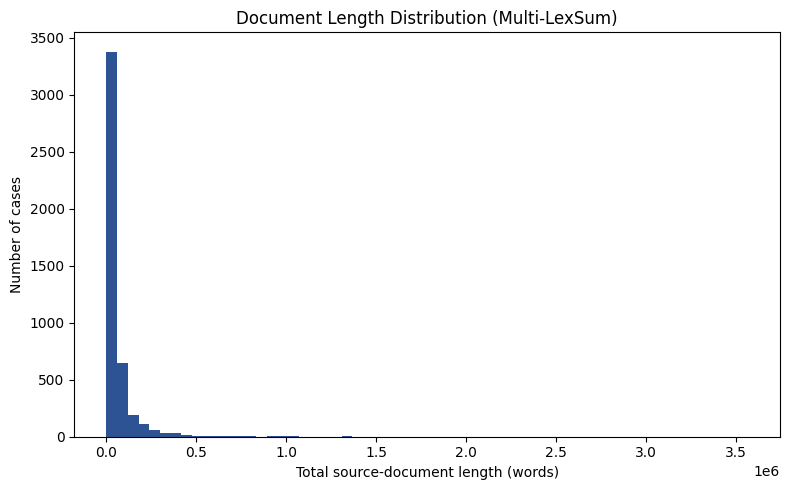

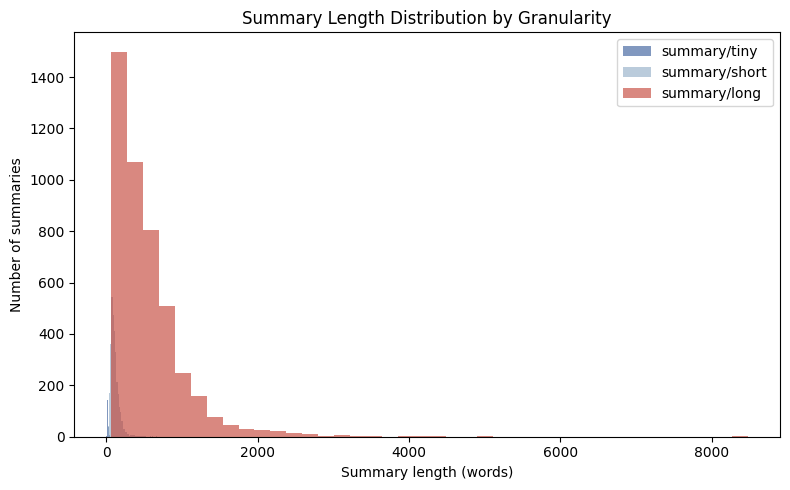

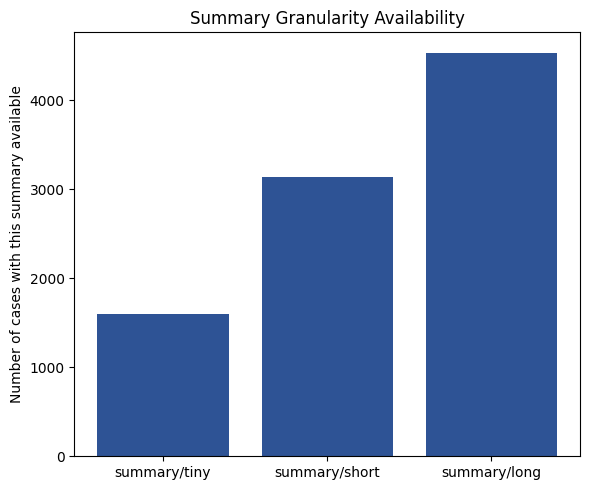

Tokenizing sampled documents: 100%|██████████| 100/100 [00:21<00:00,  4.70it/s]


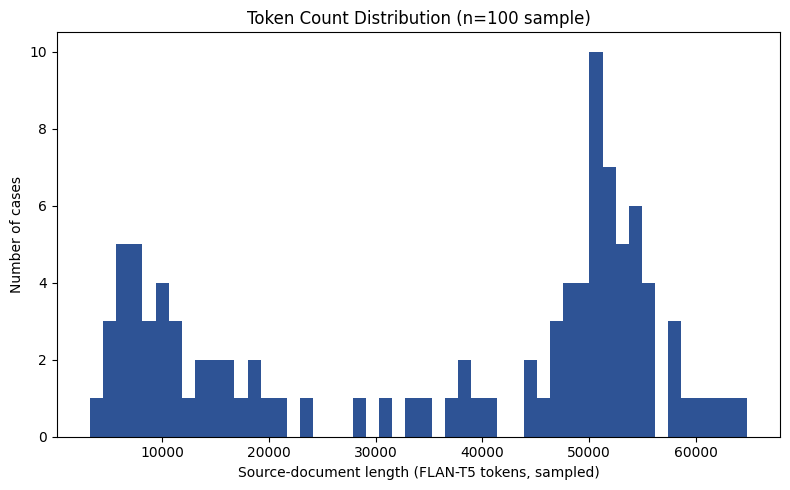

{
  "split_sizes": {
    "train": 3177,
    "validation": 454,
    "test": 908
  },
  "missing_report": {
    "train": {
      "missing_sources": 0,
      "missing_summary/tiny": 2047,
      "missing_summary/short": 967,
      "missing_summary/long": 0
    },
    "validation": {
      "missing_sources": 0,
      "missing_summary/tiny": 293,
      "missing_summary/short": 142,
      "missing_summary/long": 0
    },
    "test": {
      "missing_sources": 0,
      "missing_summary/tiny": 596,
      "missing_summary/short": 292,
      "missing_summary/long": 0
    }
  },
  "document_length_words": {
    "mean": 61538.58757435559,
    "median": 24546.0,
    "p90": 132221.80000000025,
    "max": 3565130.0
  },
  "summary_length_words": {
    "summary/tiny": {
      "count": 1603,
      "mean": 21.181534622582657,
      "median": 19.0
    },
    "summary/short": {
      "count": 3138,
      "mean": 112.96876991714468,
      "median": 100.0
    },
    "summary/long": {
      "count": 4539,
   

In [9]:
summary = run_eda(data)
print(json.dumps(summary, indent=2))

# Stage 2.1: Advanced EDA (Token Limits, Abstractiveness & Lead Bias)

--- Running Advanced EDA on a representative sample of 150 cases ---


Analyzing sample cases: 100%|██████████| 150/150 [00:31<00:00,  4.77it/s]



1. SUMMARY TOKEN DISTRIBUTIONS (Decoder Context Limits)
[SUMMARY/TINY] (n=50)
  Mean Tokens  : 34.8 | Median: 32.0 | Max: 80
  > 128 tokens : 0.0%
  > 256 tokens : 0.0%
  > 512 tokens : 0.0%
------------------------------------------------------------
[SUMMARY/SHORT] (n=99)
  Mean Tokens  : 168.8 | Median: 141.0 | Max: 693
  > 128 tokens : 63.6%
  > 256 tokens : 13.1%
  > 512 tokens : 1.0%
------------------------------------------------------------
[SUMMARY/LONG] (n=150)
  Mean Tokens  : 779.2 | Median: 571.5 | Max: 4368
  > 128 tokens : 99.3%
  > 256 tokens : 78.7%
  > 512 tokens : 55.3%
------------------------------------------------------------

2. ABSTRACTIVENESS ANALYSIS (% of Novel N-Grams not in Source)
[SUMMARY/TINY]
  Novel Unigrams (1-gram): 8.53%
  Novel Bigrams  (2-gram): 50.53%
  Novel Trigrams (3-gram): 77.65%
------------------------------------------------------------
[SUMMARY/SHORT]
  Novel Unigrams (1-gram): 5.21%
  Novel Bigrams  (2-gram): 37.62%
  Novel Trigrams 

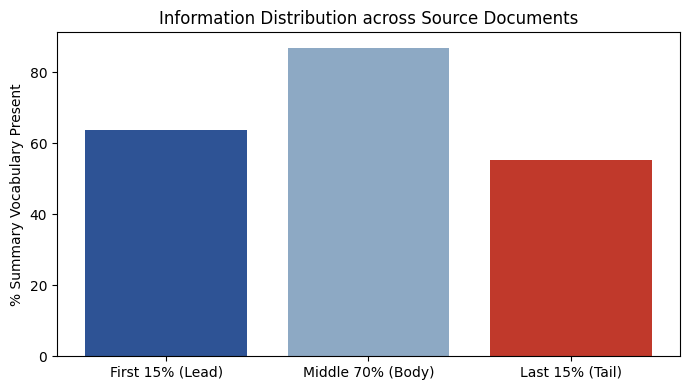

In [10]:
from collections import Counter
import re
from transformers import AutoTokenizer

def get_ngrams(words, n):
    """Generate n-grams from a list of words."""
    return set(zip(*[words[i:] for i in range(n)])) if len(words) >= n else set()

def run_advanced_eda(data, sample_size=150):
    """
    Computes:
    1. Summary token counts under FLAN-T5 (Decoder limits)
    2. Novel n-gram ratios (Abstractiveness)
    3. Source document position overlap (Lead Bias)
    """
    print(f"--- Running Advanced EDA on a representative sample of {sample_size} cases ---")

    tokenizer = AutoTokenizer.from_pretrained("google/flan-t5-small")
    all_items = [x for items in data.values() for x in items]

    rng = np.random.default_rng(42)
    sample_idx = rng.choice(len(all_items), size=sample_size, replace=False)

    granularities = ["summary/tiny", "summary/short", "summary/long"]
    summary_tokens = {g: [] for g in granularities}
    novel_ngrams = {g: {1: [], 2: [], 3: []} for g in granularities}

    lead_overlap = []   # First 15% of document
    mid_overlap = []    # Middle 70% of document
    tail_overlap = []   # Last 15% of document

    for idx in tqdm(sample_idx, desc="Analyzing sample cases"):
        case = all_items[idx]
        doc_text = " ".join(case.get("sources") or [])
        doc_words = re.findall(r'\w+', doc_text.lower())

        if not doc_words:
            continue

        doc_unigrams = set(doc_words)
        doc_bigrams = get_ngrams(doc_words, 2)
        doc_trigrams = get_ngrams(doc_words, 3)

        # 1. Summary Token Lengths & Abstractiveness
        for g in granularities:
            summary_text = case.get(g)
            if summary_text:
                # Token count for decoder
                tokens = len(tokenizer(summary_text, add_special_tokens=False)["input_ids"])
                summary_tokens[g].append(tokens)

                # Novel n-grams calculation
                sum_words = re.findall(r'\w+', summary_text.lower())
                if sum_words:
                    sum_u = set(sum_words)
                    sum_b = get_ngrams(sum_words, 2)
                    sum_t = get_ngrams(sum_words, 3)

                    novel_ngrams[g][1].append(100 * len(sum_u - doc_unigrams) / len(sum_u) if sum_u else 0)
                    novel_ngrams[g][2].append(100 * len(sum_b - doc_bigrams) / len(sum_b) if sum_b else 0)
                    novel_ngrams[g][3].append(100 * len(sum_t - doc_trigrams) / len(sum_t) if sum_t else 0)

        # 2. Lead Bias / Position Overlap (using summary/long as the ground truth)
        target_summary = case.get("summary/long") or case.get("summary/short")
        if target_summary and len(doc_words) > 50:
            sum_words_set = set(re.findall(r'\w+', target_summary.lower()))

            n = len(doc_words)
            lead_words = set(doc_words[:int(n * 0.15)])
            mid_words = set(doc_words[int(n * 0.15):int(n * 0.85)])
            tail_words = set(doc_words[int(n * 0.85):])

            # Recall of summary vocabulary in each section
            if sum_words_set:
                lead_overlap.append(len(sum_words_set & lead_words) / len(sum_words_set) * 100)
                mid_overlap.append(len(sum_words_set & mid_words) / len(sum_words_set) * 100)
                tail_overlap.append(len(sum_words_set & tail_words) / len(sum_words_set) * 100)

    # --- Print Summary Token Distribution ---
    print("\n" + "="*60)
    print("1. SUMMARY TOKEN DISTRIBUTIONS (Decoder Context Limits)")
    print("="*60)
    for g in granularities:
        counts = summary_tokens[g]
        if counts:
            print(f"[{g.upper()}] (n={len(counts)})")
            print(f"  Mean Tokens  : {np.mean(counts):.1f} | Median: {np.median(counts):.1f} | Max: {np.max(counts)}")
            print(f"  > 128 tokens : {100 * sum(c > 128 for c in counts) / len(counts):.1f}%")
            print(f"  > 256 tokens : {100 * sum(c > 256 for c in counts) / len(counts):.1f}%")
            print(f"  > 512 tokens : {100 * sum(c > 512 for c in counts) / len(counts):.1f}%")
            print("-" * 60)

    # --- Print Abstractiveness Stats ---
    print("\n" + "="*60)
    print("2. ABSTRACTIVENESS ANALYSIS (% of Novel N-Grams not in Source)")
    print("="*60)
    for g in granularities:
        if novel_ngrams[g][1]:
            print(f"[{g.upper()}]")
            print(f"  Novel Unigrams (1-gram): {np.mean(novel_ngrams[g][1]):.2f}%")
            print(f"  Novel Bigrams  (2-gram): {np.mean(novel_ngrams[g][2]):.2f}%")
            print(f"  Novel Trigrams (3-gram): {np.mean(novel_ngrams[g][3]):.2f}%")
            print("-" * 60)

    # --- Print & Plot Lead Bias Analysis ---
    print("\n" + "="*60)
    print("3. LEAD BIAS / POSITION OVERLAP (% of Summary Vocabulary)")
    print("="*60)
    print(f"  First 15% of Source (Lead) : {np.mean(lead_overlap):.2f}% vocabulary overlap")
    print(f"  Middle 70% of Source (Body): {np.mean(mid_overlap):.2f}% vocabulary overlap")
    print(f"  Last 15% of Source (Tail)  : {np.mean(tail_overlap):.2f}% vocabulary overlap")

    # Visualization: Positional Overlap Bar Chart
    plt.figure(figsize=(7, 4))
    sections = ['First 15% (Lead)', 'Middle 70% (Body)', 'Last 15% (Tail)']
    overlaps = [np.mean(lead_overlap), np.mean(mid_overlap), np.mean(tail_overlap)]
    plt.bar(sections, overlaps, color=['#2E5395', '#8DA9C4', '#C0392B'])
    plt.ylabel("% Summary Vocabulary Present")
    plt.title("Information Distribution across Source Documents")
    plt.tight_layout()
    plt.savefig(OUT_DIR / "lead_bias_distribution.png", dpi=150)
    plt.show()

# Run the function
run_advanced_eda(data, sample_size=150)

# Stage 2.2: OCR Text Noise & Artifact Inspection

In [11]:
import string

def inspect_ocr_artifacts(data, num_samples=3):
    """
    Finds documents flagged with is_ocr=True in sources_metadata
    and prints snippets alongside non-alphanumeric noise stats.
    """
    print("="*60)
    print("4. OCR TEXT ARTIFACT & NOISE INSPECTION")
    print("="*60)

    ocr_snippets = []
    clean_snippets = []

    all_items = [x for items in data.values() for x in items]

    for case in all_items:
        sources = case.get("sources") or []
        metadata = case.get("sources_metadata") or []

        for i, text in enumerate(sources):
            if i < len(metadata):
                is_ocr = metadata[i].get("is_ocr", False)
                doc_type = metadata[i].get("doc_type", "unknown")

                if is_ocr and len(ocr_snippets) < num_samples and len(text.strip()) > 200:
                    ocr_snippets.append((doc_type, text))
                elif not is_ocr and len(clean_snippets) < num_samples and len(text.strip()) > 200:
                    clean_snippets.append((doc_type, text))

        if len(ocr_snippets) >= num_samples and len(clean_snippets) >= num_samples:
            break

    def compute_noise_metrics(text):
        total_chars = len(text)
        if total_chars == 0:
            return 0, 0
        symbols = sum(1 for c in text if c in string.punctuation)
        digits = sum(1 for c in text if c.isdigit())
        return (symbols / total_chars) * 100, (digits / total_chars) * 100

    print("\n--- SAMPLE OCR-DERIVED DOCUMENTS (is_ocr = True) ---")
    for i, (dtype, text) in enumerate(ocr_snippets, 1):
        sym_pct, num_pct = compute_noise_metrics(text)
        print(f"\n[OCR Sample {i} - Type: {dtype}] (Punctuation Noise: {sym_pct:.1f}%, Numeric: {num_pct:.1f}%)")
        print(f"Snippet: {text[:350].strip()}...")
        print("-" * 50)

    print("\n--- SAMPLE BORN-DIGITAL DOCUMENTS (is_ocr = False) ---")
    for i, (dtype, text) in enumerate(clean_snippets, 1):
        sym_pct, num_pct = compute_noise_metrics(text)
        print(f"\n[Digital Sample {i} - Type: {dtype}] (Punctuation Noise: {sym_pct:.1f}%, Numeric: {num_pct:.1f}%)")
        print(f"Snippet: {text[:350].strip()}...")
        print("-" * 50)

# Run the inspection
inspect_ocr_artifacts(data)

4. OCR TEXT ARTIFACT & NOISE INSPECTION

--- SAMPLE OCR-DERIVED DOCUMENTS (is_ocr = True) ---

[OCR Sample 1 - Type: Complaint] (Punctuation Noise: 4.6%, Numeric: 5.6%)
Snippet: Case 1:05-cv-00530-D Document 1-1 Filed 09/19/2005 Page 1 of 6

IN

THE

UNITED

STATES

DISTRICT

FILD COUR T

P19

.05

Nl

el

.s

FOR THE SOUTHERN DISTRICT OF ALABAMA

SOUTHERN DIVISION

EQUAL EMPLOYMENT OPPORTUNITY ]

COMMISSION, ]

] Plaintiff, ] Civil Action No. OSS- 0'53a -~

v.

]

]
COMPLAINT

] HOUSE OF PHILADELPHIA CENTER, INC . ]

JURY...
--------------------------------------------------

[OCR Sample 2 - Type: Complaint] (Punctuation Noise: 4.6%, Numeric: 4.0%)
Snippet: Case 1:05-cv-00530-KD-M Document 9-t Filed 02/21/2006 Page 1 of 6

IN THE UNITED STATES DISTRICT COURT FOR THE SOUTHERN DISTRICT OF ALABAMA
SOUTHERN DIVISION

EQUAL EMPLOYMENT

)

OPPORTUNITY COMMISSION,

)

)

- plaintiff,.

.).. :-.. ,

..

vs.
HOUSE OF PHILADELPHIA CENTER, INC.,
Defendant.

)

CIVIL ACTION NO. 05-0530-D

)

)

)

## Document Type Analysis

Document Type                     Count    Avg Words    % OCR
------------------------------------------------------------
Order/Opinion                     14972         4432     7.7%
Pleading / Motion / Brief          7803         9032     7.5%
Complaint                          6885         7373    20.3%
Docket                             4941         8127     0.7%
Settlement Agreement               2273         4991    32.1%
Monitor/Expert/Receiver Report      999        26563    12.9%
Press Release                       513         1177    10.3%
Declaration/Affidavit               293        10769    10.9%
Notice Letter                       259         1920    21.2%
Findings Letter/Report              245        10749    39.6%
Other                               229         5841    34.1%
Magistrate Report/Recommendation      199         6306     5.0%
Correspondence                      135         1888    48.9%
Transcript                          122        21252    23.0%
Statute

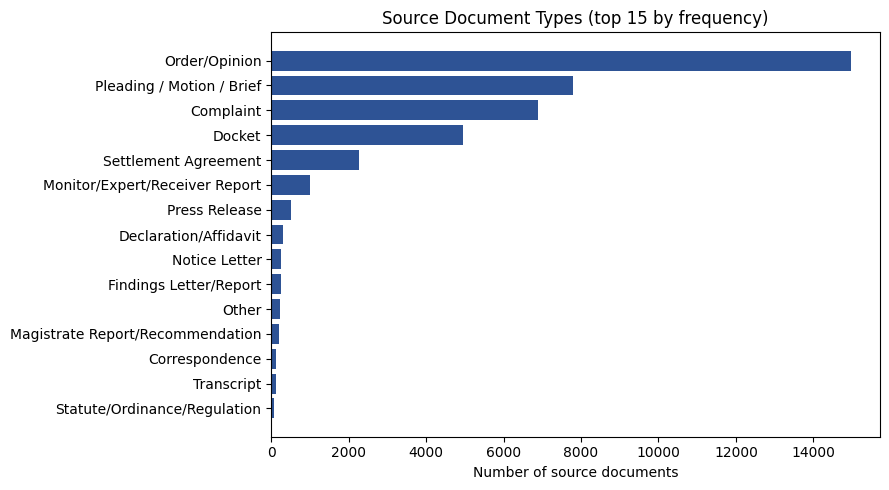

In [12]:
from collections import Counter

def analyze_doc_types(data):
    """
    Looks at sources_metadata (only present in the v20230518 version we loaded)
    to see which document types show up, how common each is, and how much text
    each type typically contributes — so we know which types are worth keeping
    when we build the document-selection strategy in Stage 3.
    """
    type_counts = Counter()
    type_word_totals = Counter()
    type_doc_counts = Counter()
    ocr_counts = Counter()

    all_items = [x for items in data.values() for x in items]

    for case in all_items:
        sources = case.get("sources") or []
        metadata = case.get("sources_metadata") or []
        # metadata and sources are parallel lists (same order, same length)
        for i, doc_text in enumerate(sources):
            if i >= len(metadata):
                break
            doc_type = metadata[i].get("doc_type", "unknown") or "unknown"
            is_ocr = metadata[i].get("is_ocr", False)

            type_counts[doc_type] += 1
            type_word_totals[doc_type] += word_count(doc_text)
            type_doc_counts[doc_type] += 1
            ocr_counts[doc_type] += 1 if is_ocr else 0

    # Build a summary table
    rows = []
    for doc_type, count in type_counts.most_common():
        avg_words = type_word_totals[doc_type] / count if count else 0
        pct_ocr = 100 * ocr_counts[doc_type] / count if count else 0
        rows.append((doc_type, count, avg_words, pct_ocr))

    print(f"{'Document Type':<30} {'Count':>8} {'Avg Words':>12} {'% OCR':>8}")
    print("-" * 60)
    for doc_type, count, avg_words, pct_ocr in rows:
        print(f"{doc_type:<30} {count:>8} {avg_words:>12.0f} {pct_ocr:>7.1f}%")

    # Plot: how many documents of each type exist
    plt.figure(figsize=(9, 5))
    types = [r[0] for r in rows[:15]]  # top 15 types
    counts = [r[1] for r in rows[:15]]
    plt.barh(types[::-1], counts[::-1], color="#2E5395")
    plt.xlabel("Number of source documents")
    plt.title("Source Document Types (top 15 by frequency)")
    plt.tight_layout()
    plt.savefig(OUT_DIR / "doc_type_frequency.png", dpi=150)
    plt.show()

    return rows

doc_type_rows = analyze_doc_types(data)

# Stage 3: Preprocessing & Tokenisation Pipeline

In [13]:
from datasets import Dataset, DatasetDict
from transformers import AutoTokenizer

def build_smart_tokenized_dataset(parsed_data, tokenizer_name="google/flan-t5-small", max_source_length=1024, max_target_length=256):
    """
    Builds the dataset by extracting the most information-dense sections of the
    source documents (based on EDA) and tokenizes them for FLAN-T5.
    """
    print(f"Initializing tokenizer: {tokenizer_name}")
    tokenizer = AutoTokenizer.from_pretrained(tokenizer_name)
    hf_splits = {}

    for split_name, cases in parsed_data.items():
        inputs = []
        targets = []

        for case in cases:
            target_summary = case.get("summary/short")
            sources = case.get("sources")

            # Skip invalid entries
            if not target_summary or not sources:
                continue

            # Combine all source documents into one sequence
            full_text = " ".join(sources)
            words = full_text.split()

            # --- SMART EXTRACTION ---
            # EDA showed the middle 70% contains ~87% of summary vocabulary.
            # We extract the first 250 words (context) and 700 words from the middle.
            if len(words) > 950:
                mid_start = int(len(words) * 0.15)  # Start of the middle 70%
                extracted_text = " ".join(words[:250]) + " ... [TEXT OMITTED] ... " + " ".join(words[mid_start:mid_start+700])
            else:
                extracted_text = full_text

            # Add instruction prefix for FLAN-T5
            prompt = "summarize civil rights legal document: " + extracted_text

            inputs.append(prompt)
            targets.append(target_summary)

        # Convert to Hugging Face Dataset
        hf_splits[split_name] = Dataset.from_dict({
            "document": inputs,
            "summary": targets
        })
        print(f"  {split_name.capitalize()}: {len(targets)} valid cases processed.")

    dataset_dict = DatasetDict(hf_splits)

    # --- TOKENIZATION ---
    def preprocess_function(examples):
        model_inputs = tokenizer(
            examples["document"],
            max_length=max_source_length,
            truncation=True,
            padding="max_length"
        )
        labels = tokenizer(
            text_target=examples["summary"],
            max_length=max_target_length,
            truncation=True,
            padding="max_length"
        )
        model_inputs["labels"] = labels["input_ids"]
        return model_inputs

    print("\nTokenizing datasets (this may take a few minutes)...")
    tokenized_datasets = dataset_dict.map(
        preprocess_function,
        batched=True,
        remove_columns=["document", "summary"]
    )
    print("Tokenization complete! Pipeline ready for training.")

    return tokenized_datasets, tokenizer

# Run the pipeline targeting 'summary/short'
tokenized_dataset, flan_tokenizer = build_smart_tokenized_dataset(data)

# Verify the tensor shapes
print(f"\nSample Input Tensor Shape : {len(tokenized_dataset['train'][0]['input_ids'])} tokens")
print(f"Sample Target Tensor Shape: {len(tokenized_dataset['train'][0]['labels'])} tokens")

Initializing tokenizer: google/flan-t5-small
  Train: 2210 valid cases processed.
  Validation: 312 valid cases processed.
  Test: 616 valid cases processed.

Tokenizing datasets (this may take a few minutes)...


Map:   0%|          | 0/2210 [00:00<?, ? examples/s]

Map:   0%|          | 0/312 [00:00<?, ? examples/s]

Map:   0%|          | 0/616 [00:00<?, ? examples/s]

Tokenization complete! Pipeline ready for training.

Sample Input Tensor Shape : 1024 tokens
Sample Target Tensor Shape: 256 tokens


# Stage 4: Teacher Adaptation (FLAN-T5 Large)                 {SMOKE TEST}